In [48]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

import re
import pandas as pd
import nltk
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.metrics import classification_report
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import randint, uniform
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, jaccard_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer
from gensim.models import Word2Vec, FastText
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.multioutput import MultiOutputClassifier

In [2]:
%config InlineBackend.figure_format="retina"  # For high DPI display

# Data Processing

We have two files from which we're going to extract the data needed for our dataset.

The data is extracted from both files and cleaned, then the two resulting dataframes are merged to obtain the final dataset with titles of the movies and their corresponding genres and plots.

In [3]:
filtered_lines = []
start_reading = False

with open("genres.list", "r", encoding="ISO-8859-1") as f:
    for line in f:
        if "8: THE GENRES LIST" in line:
            start_reading = True
            continue

        if start_reading:
            filtered_lines.append(line.strip())


filtered_lines = filtered_lines[2:]
data = []
for i in filtered_lines:
    unpack = i.split("\t")
    data.append((unpack[0], unpack[-1]))

genres_df = pd.DataFrame(data, columns=["Title", "Genre"])
genres_df['Title'] = genres_df['Title'].str.replace(r'\(.*\)', '', regex=True)
genres_df['Title'] = genres_df['Title'].str.replace(r'["{}]',"",regex=True).str.strip()
genres_df.head()

,Title,Genre
0,!Next?,Documentary
1,#1 Single,Reality-TV
2,#15SecondScare,Horror
3,#15SecondScare,Short
4,#15SecondScare,Thriller


In [4]:
with open("plot.list", "r", encoding="ISO-8859-1") as file:
    lines = file.readlines()

movies = []
current_movie = None
current_plot = []

for line in lines:
    mv_match = re.match(r"MV: (.*)", line)
    pl_match = re.match(r"PL: (.*)", line)

    if mv_match:
        if current_movie and current_plot:
            movies.append({"Title": current_movie, "Plot": " ".join(current_plot)})
        current_movie = mv_match.group(1).strip()
        current_plot = []

    elif pl_match and current_movie:
        current_plot.append(pl_match.group(1).strip())

if current_movie and current_plot:
    movies.append({"Title": current_movie, "Plot": " ".join(current_plot)})

plot_df = pd.DataFrame(movies)
plot_df['Title'] = plot_df['Title'].str.replace(r'\(.*\)', '', regex=True)
plot_df['Title'] = plot_df['Title'].str.replace(r'["{}]',"",regex=True).str.strip()
plot_df.head()

,Title,Plot
0,#7DaysLater,#7dayslater is an interactive comedy series fe...
1,#BlackLove,"This week, the five women work on getting what..."
2,#BlackLove,"With just one week left in the workshops, the ..."
3,#BlackLove,All of the women are struggling with what make...
4,#BlackLove,All of the women start making strides towards ...


In [5]:
df = genres_df.merge(plot_df, on='Title', how='inner')
df.head()

,Title,Genre,Plot
0,#7DaysLater,Comedy,#7dayslater is an interactive comedy series fe...
1,#BlackLove,Reality-TV,"This week, the five women work on getting what..."
2,#BlackLove,Reality-TV,"With just one week left in the workshops, the ..."
3,#BlackLove,Reality-TV,All of the women are struggling with what make...
4,#BlackLove,Reality-TV,All of the women start making strides towards ...


Out of the genres present in the dataset, 20 are selected for the study. The movies of other genres are removed.

Some of the movies in the dataset have no titles. We choose to remove them as well.

Lastly, movies with multiple genres have repeated rows where only the genre differs. We decide to group the movies by their titles and plots to obtain a compact dataset with movies occurring only once and with their corresponding genres stores in a tuple.

In [6]:
genres = ['Comedy', 'Romance', 'Action', 'Drama', 'Horror',
       'Family', 'Sci-Fi', 'Crime', 'Mystery', 'Biography',
       'Adventure', 'History', 'War', 'Fantasy',
       'Thriller', 'Sport', 'Documentary', 'Animation',
       'Adult', 'Western']

df = df[df["Genre"].isin(genres)]
df = df[df['Title'] != ""]
df = df.groupby(['Title', 'Plot'])['Genre'].agg(tuple).reset_index()
df["Genre"] = df["Genre"].apply(lambda x: tuple(set(x)))
df = df.drop_duplicates(subset=["Title", "Genre"])
df.head()

,Title,Plot,Genre
0,#,The night falls on the big city and a hooded f...,"(Animation, Comedy)"
1,#1,After reaching #1 at Mutual of New York and se...,"(Documentary, Animation, Drama, Comedy)"
2,#1 Cheerleader Camp,When they're hired to work at a cheerleading c...,"(Comedy,)"
3,#1 Serial Killer,Years of seething rage against the racism he's...,"(Horror,)"
4,#1 at the Apocalypse Box Office,"Jules is, self declared, the most useless pers...","(Sci-Fi, Comedy)"


Next, we remove the movies having a number of genres bigger than six since these are rare and they wouldn't be useful for our task.

In [7]:
df["num_cat"] = df["Genre"].apply(lambda x: len(x))
df = df[df["num_cat"] <= 6]
df = df.reset_index()
df.head()

,index,Title,Plot,Genre,num_cat
0,0,#,The night falls on the big city and a hooded f...,"(Animation, Comedy)",2
1,1,#1,After reaching #1 at Mutual of New York and se...,"(Documentary, Animation, Drama, Comedy)",4
2,2,#1 Cheerleader Camp,When they're hired to work at a cheerleading c...,"(Comedy,)",1
3,3,#1 Serial Killer,Years of seething rage against the racism he's...,"(Horror,)",1
4,4,#1 at the Apocalypse Box Office,"Jules is, self declared, the most useless pers...","(Sci-Fi, Comedy)",2


Now, we show the number of movies per genre to have an idea about the distribution of the movies.

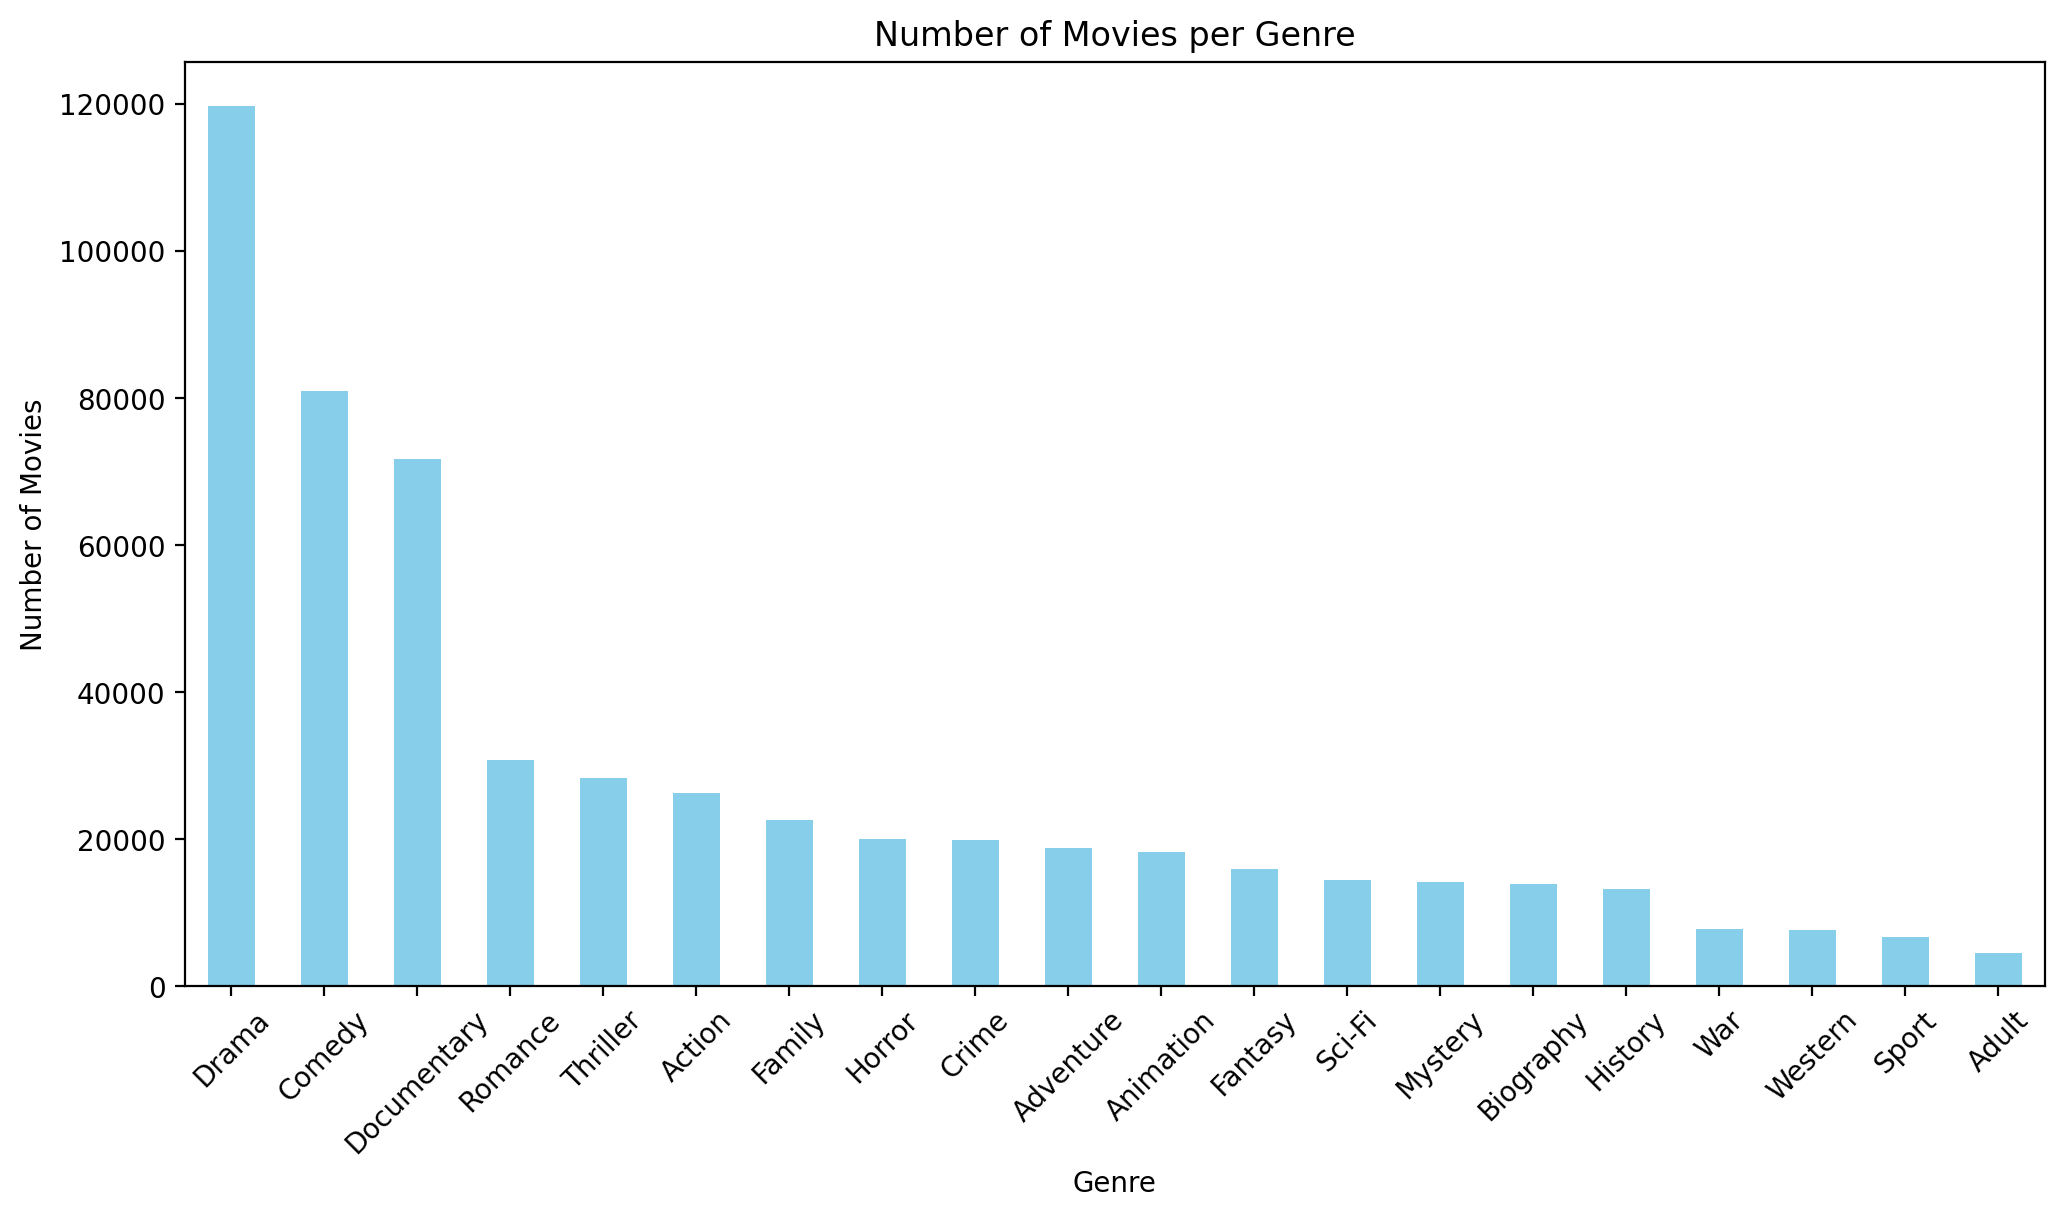

In [8]:
genre_counts = df.explode('Genre')['Genre'].value_counts()

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Movies per Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

Next, we check the disribution of the number of genres per movie.

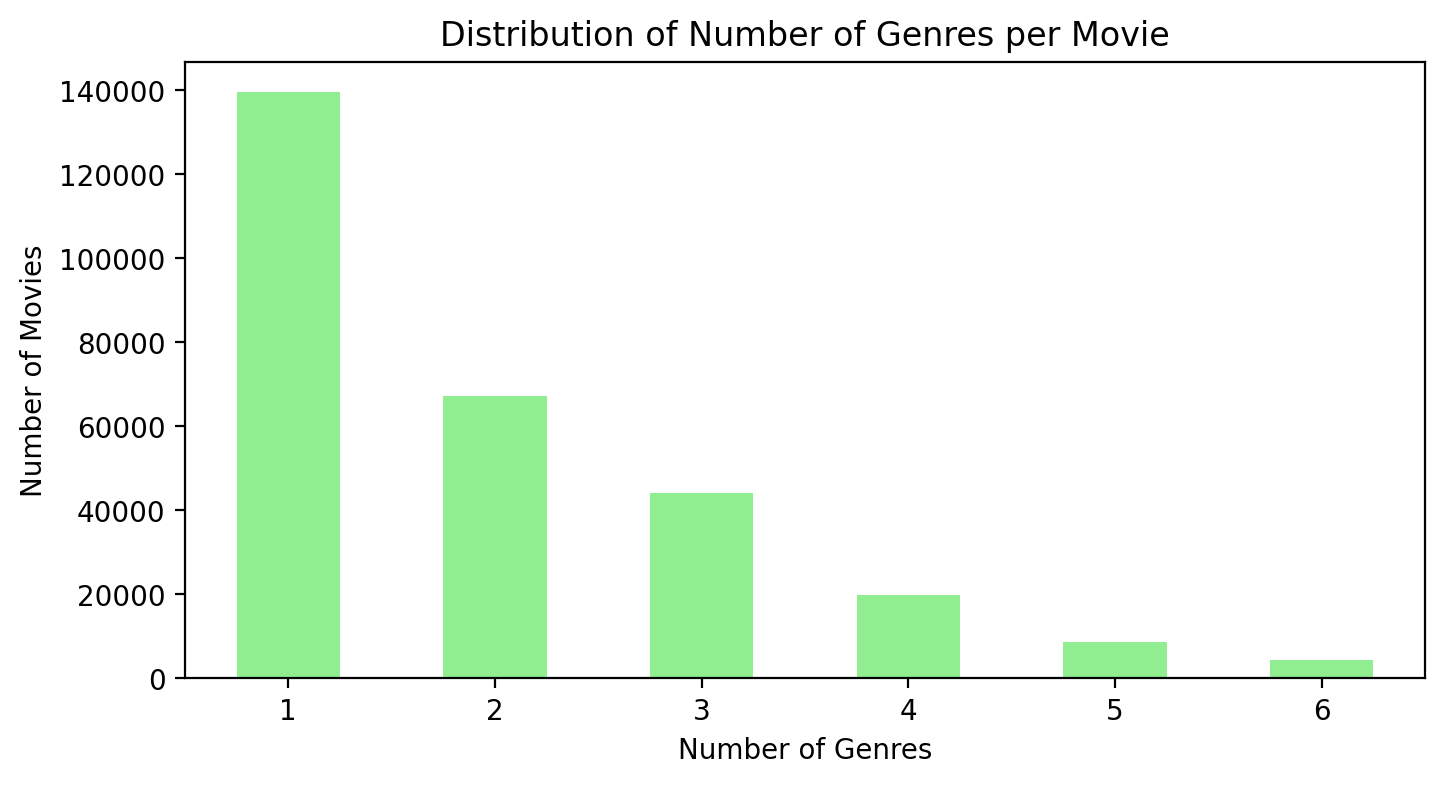

In [9]:
genre_per_movie_counts = df['Genre'].apply(len).value_counts().sort_index()

plt.figure(figsize=(8, 4))
genre_per_movie_counts.plot(kind='bar', color='lightgreen')
plt.title('Distribution of Number of Genres per Movie')
plt.xlabel('Number of Genres')
plt.ylabel('Number of Movies')
plt.xticks(rotation=0)
plt.show()

We plot the percentage of movies by number of genres.

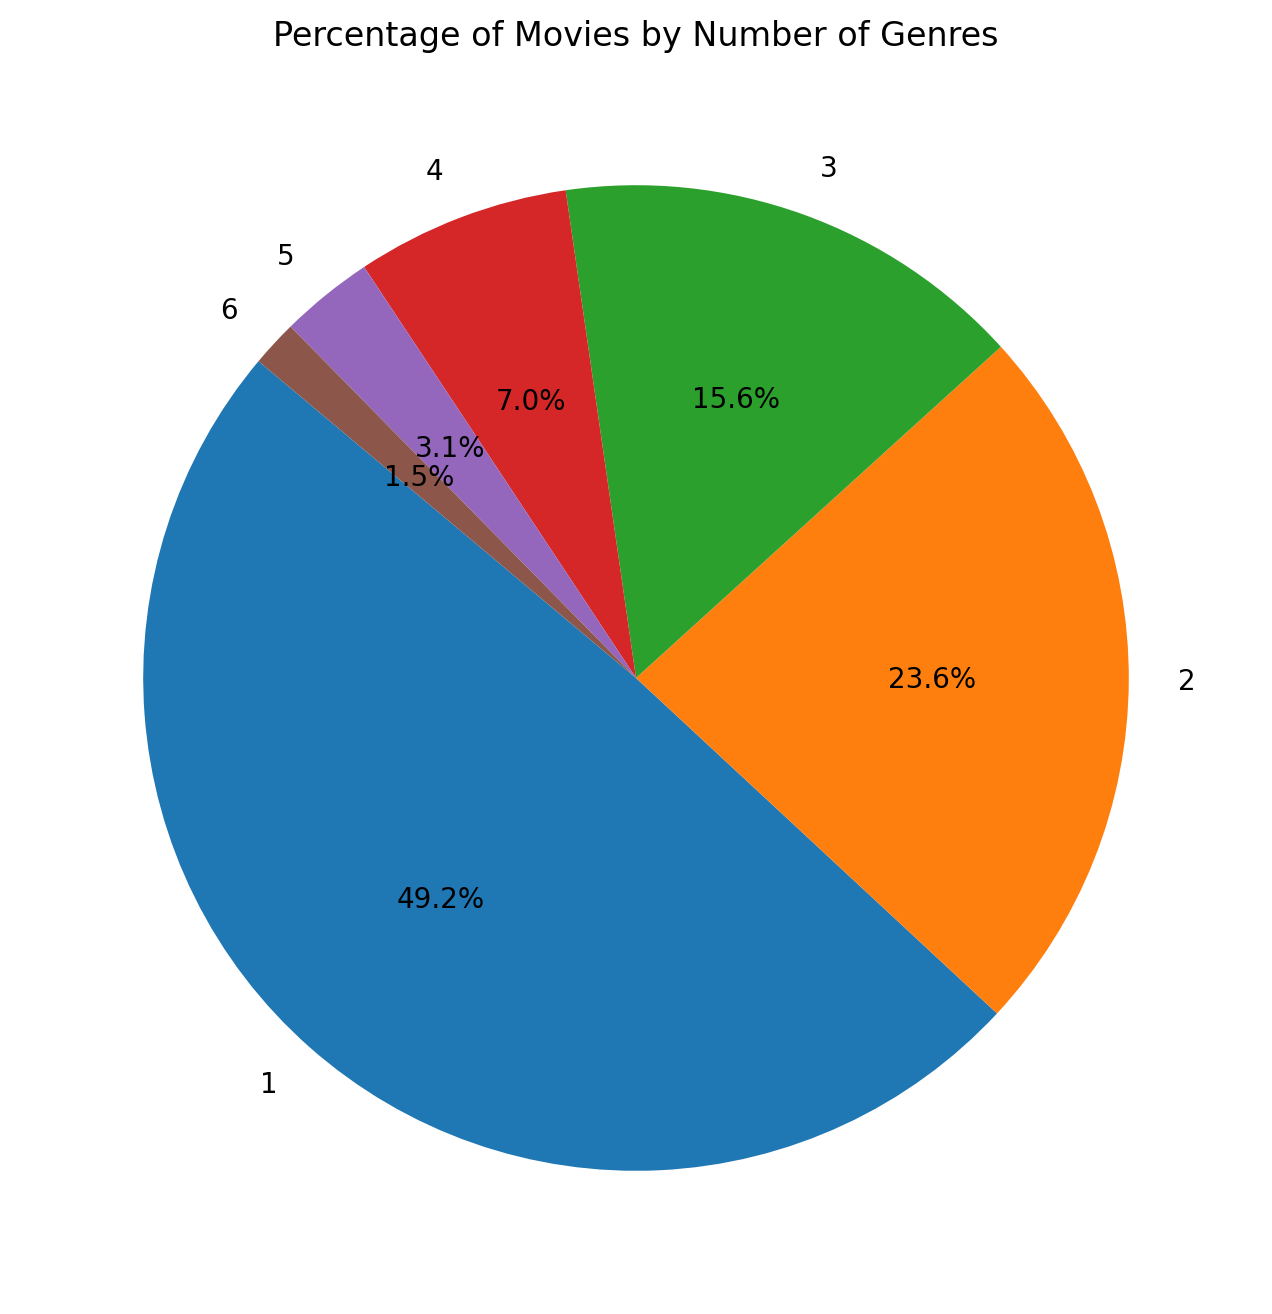

In [10]:
df_percentages = df["num_cat"].value_counts(normalize=True).reset_index()
df_percentages.columns = ["num_cat", "percentage"]
df_percentages["percentage"] = df_percentages["percentage"] * 100

plt.figure(figsize=(8, 8))
plt.pie(df_percentages['percentage'], labels=df_percentages['num_cat'], autopct='%1.1f%%', startangle=140)
plt.title('Percentage of Movies by Number of Genres')
plt.show()

This is the final version of the dataset after data processing.

In [11]:
df = df.loc[:, ["Plot", "Genre"]]
df.head()

,Plot,Genre
0,The night falls on the big city and a hooded f...,"(Animation, Comedy)"
1,After reaching #1 at Mutual of New York and se...,"(Documentary, Animation, Drama, Comedy)"
2,When they're hired to work at a cheerleading c...,"(Comedy,)"
3,Years of seething rage against the racism he's...,"(Horror,)"
4,"Jules is, self declared, the most useless pers...","(Sci-Fi, Comedy)"


# Tokenisation

In this section, we perform tokenization and we keep the output in our dataframe as it will be used all along our study.

We're going to keep only plots that have 200 tokens or less.

In [12]:
nltk.data.path.append('/root/nltk_data')

nltk.download("punkt_tab")
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/idrissamahamoudoudicko/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/idrissamahamoudoudicko/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
stop_words = set(stopwords.words('english'))

# Function to Tokenize and Remove Stopwords
def clean_plot(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]
    return tokens if len(tokens) <= 200 else None

df["Tokenized"] = df["Plot"].apply(clean_plot)
df = df.dropna(subset=["Tokenized"])
df = df.reset_index()
df.head()

,index,Plot,Genre,Tokenized
0,0,The night falls on the big city and a hooded f...,"(Animation, Comedy)","[night, falls, big, city, hooded, figure, emer..."
1,1,After reaching #1 at Mutual of New York and se...,"(Documentary, Animation, Drama, Comedy)","[reaching, mutual, new, york, several, financi..."
2,2,When they're hired to work at a cheerleading c...,"(Comedy,)","[hired, work, cheerleading, camp, summer, two,..."
3,3,Years of seething rage against the racism he's...,"(Horror,)","[years, seething, rage, racism, experienced, c..."
4,4,"Jules is, self declared, the most useless pers...","(Sci-Fi, Comedy)","[jules, self, declared, useless, person, post,..."


Since our dataset contains multiple classes, the target variable is stored as a tuple with categorical values. We construct a matrix y, where each row represents a movie and each column corresponds to a specific genre. If a movie belongs to a particular genre, the respective column is assigned a value of 1; otherwise, it is assigned 0.

In [14]:
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df["Genre"])
genre_names = mlb.classes_

------------

# TF-IDF

In this section, we use TF-IDF to classify movies given their plots.

The following models are used to perform the classification task:
- Logistic Regression (One Vs Rest)
- SVC
- XGBoost

In [15]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['Plot'])

In [16]:
X.shape

(277741, 5000)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 236079
Testing samples: 41662


Before making our models, we visualise the PCA projection of the movies in order to get an idea about the variety of the textual features of the movies from the different genres.

In order to simplify the task, only movies having one genre were considered, which amounts to 50% of the total data. (It's more complicated to visualise also the movies having multiple genres)

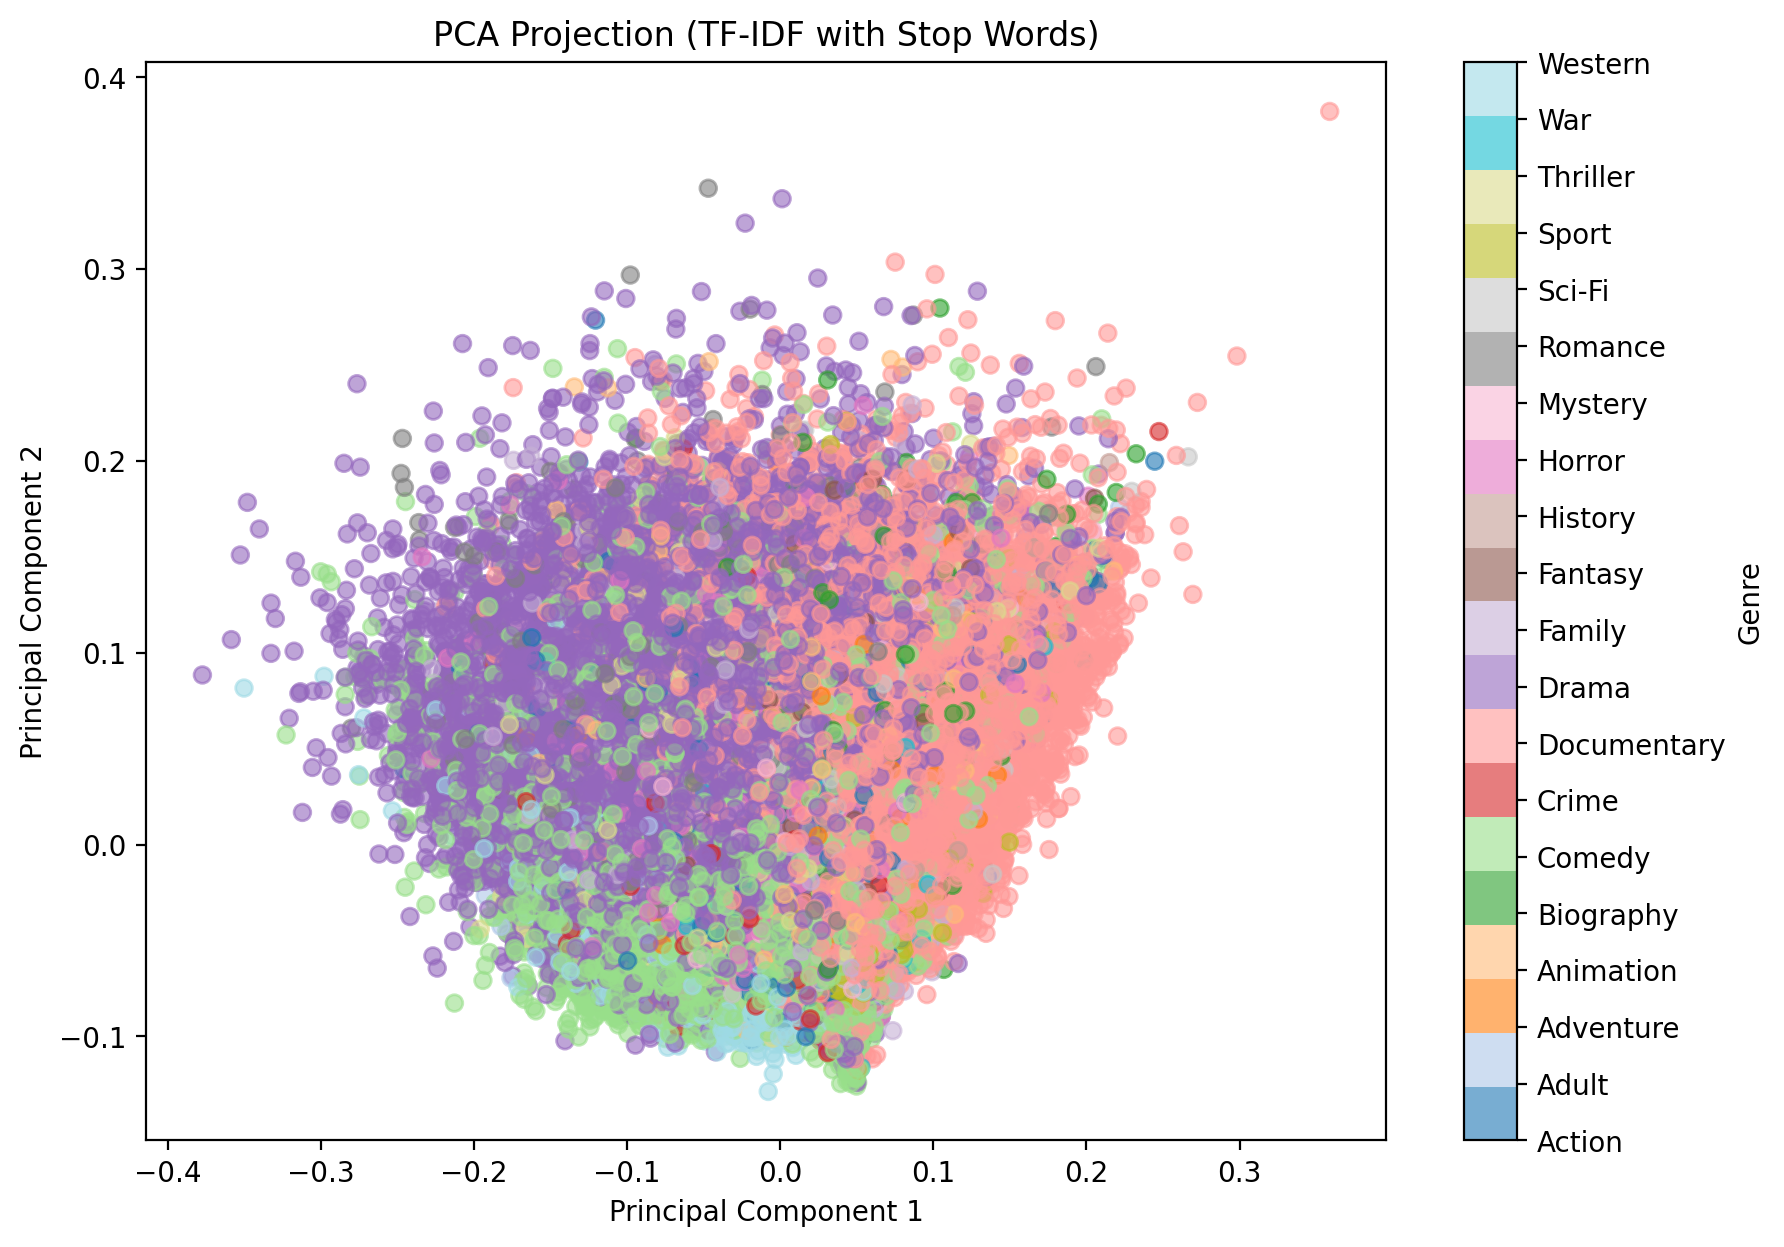

In [18]:
# Filter data with only single-genre movies
single_genre_mask = df['Genre'].apply(lambda x: len(x) == 1)

# Extract the plots and their single genre labels
single_genre_plots = df.loc[single_genre_mask, 'Plot']
single_genre_labels = df.loc[single_genre_mask, 'Genre'].apply(lambda x: x[0])

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_single_genre = vectorizer.fit_transform(single_genre_plots)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_single_genre.toarray())

def plot_pca_projection(pca_data, labels, title):
    unique_labels = np.unique(labels)
    label_to_int = {label: i for i, label in enumerate(unique_labels)}
    color_labels = [label_to_int[label] for label in labels]

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1], c=color_labels, cmap="tab20", alpha=0.6)
    cbar = plt.colorbar(scatter, ticks=range(len(unique_labels)))
    cbar.set_ticklabels(unique_labels)
    cbar.set_label('Genre')
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(title)
    plt.show()

plot_pca_projection(X_pca, single_genre_labels, "PCA Projection (TF-IDF with Stop Words)")

The PCA projection of TF-IDF vectors for movie plots shows significant overlap among genres, indicating that many movies share common textual features, which complicates genre prediction based solely on plot descriptions. Visible clusters are sparse, suggesting that distinguishing genres using TF-IDF alone may be challenging. One thing to keep in mind is the loss of information inherent in dimensionality reduction. Therefore we will check next if the observation is correct and if this overlap underscores the necessity for more sophisticated modeling approaches.

Next, we define a function returning some metrics that will be useful for our analysis:

In [19]:
def metrics(y_test, y_pred, genre_names):
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    f1 = f1_score(y_test, y_pred, average='micro')
    print(f"F1 Score: {f1:.4f}")

    jaccard_weighted = jaccard_score(y_test, y_pred, average='samples')
    print(f"Jaccard Index (Samples): {jaccard_weighted:.4f}")

    hit_rate = np.mean(np.sum(y_test * y_pred, axis=1) > 0)
    print(f"Hit Rate: {hit_rate:.4f}")

    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=genre_names))

### Logistic Regression

In [20]:
model = Pipeline([
    ('clf', OneVsRestClassifier(LogisticRegression(solver='liblinear')))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

metrics(y_test, y_pred, genre_names)

Accuracy: 0.2685
F1 Score: 0.5038
Jaccard Index (Samples): 0.4370
Hit Rate: 0.6724

Classification Report:
               precision    recall  f1-score   support

      Action       0.66      0.23      0.34      3864
       Adult       0.53      0.05      0.08       695
   Adventure       0.57      0.10      0.17      2726
   Animation       0.76      0.24      0.36      2699
   Biography       0.47      0.05      0.10      2084
      Comedy       0.71      0.49      0.58     11723
       Crime       0.59      0.20      0.29      3020
 Documentary       0.84      0.73      0.78     10561
       Drama       0.70      0.63      0.66     17434
      Family       0.64      0.11      0.19      3374
     Fantasy       0.54      0.10      0.17      2321
     History       0.44      0.06      0.10      1945
      Horror       0.76      0.31      0.45      2947
     Mystery       0.49      0.06      0.10      2118
     Romance       0.54      0.14      0.22      4501
      Sci-Fi       0.73    

### SVC

In [21]:
model = Pipeline([
    ('clf', OneVsRestClassifier(LinearSVC()))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

metrics(y_test, y_pred, genre_names)

Accuracy: 0.2705
F1 Score: 0.4938
Jaccard Index (Samples): 0.4320
Hit Rate: 0.6617

Classification Report:
               precision    recall  f1-score   support

      Action       0.70      0.20      0.31      3864
       Adult       0.56      0.03      0.05       695
   Adventure       0.61      0.07      0.12      2726
   Animation       0.79      0.22      0.34      2699
   Biography       0.54      0.02      0.03      2084
      Comedy       0.71      0.48      0.57     11723
       Crime       0.60      0.16      0.25      3020
 Documentary       0.83      0.73      0.78     10561
       Drama       0.69      0.63      0.66     17434
      Family       0.73      0.08      0.14      3374
     Fantasy       0.58      0.07      0.12      2321
     History       0.44      0.02      0.04      1945
      Horror       0.76      0.31      0.44      2947
     Mystery       0.53      0.03      0.05      2118
     Romance       0.55      0.11      0.18      4501
      Sci-Fi       0.73    

### XGBoost

In [22]:
model = XGBClassifier(eval_metric='logloss', objective='binary:logistic')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

metrics(y_test, y_pred, genre_names)

Accuracy: 0.2229
F1 Score: 0.4386
Jaccard Index (Samples): 0.3607
Hit Rate: 0.5587

Classification Report:
               precision    recall  f1-score   support

      Action       0.65      0.16      0.26      3864
       Adult       0.55      0.05      0.09       695
   Adventure       0.55      0.09      0.15      2726
   Animation       0.78      0.21      0.33      2699
   Biography       0.44      0.04      0.07      2084
      Comedy       0.76      0.31      0.44     11723
       Crime       0.55      0.16      0.25      3020
 Documentary       0.85      0.62      0.71     10561
       Drama       0.69      0.55      0.61     17434
      Family       0.71      0.08      0.15      3374
     Fantasy       0.54      0.08      0.14      2321
     History       0.38      0.04      0.08      1945
      Horror       0.73      0.27      0.39      2947
     Mystery       0.46      0.06      0.10      2118
     Romance       0.53      0.11      0.18      4501
      Sci-Fi       0.71    

------------

# Word2vec

In this section, we use Word2Vec embedding trained from scratch.

The models used for the classification task are:
- XGBoost
- GRU
- CNN

In [23]:
word2vec_model = Word2Vec(sentences=df["Tokenized"], vector_size=100, window=5, min_count=1, workers=4)

In [24]:
def get_sentence_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

df["W2V Embedding"] = df["Tokenized"].apply(lambda x: get_sentence_embedding(x, word2vec_model))
X = np.vstack(df["W2V Embedding"].values)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

### XGBoost

In [26]:
pipeline_xgb = Pipeline([
    ('pca', PCA()),
    ('xgb', XGBClassifier(objective="binary:logistic", use_label_encoder=False, eval_metric="logloss"))
])

param_dist_xgb = {
    'pca__n_components': randint(10, 80),
    'xgb__n_estimators': randint(50, 300),
    'xgb__max_depth': randint(2, 10),
    'xgb__learning_rate': uniform(0.01, 0.2),
}

random_search_xgb = RandomizedSearchCV(pipeline_xgb, param_distributions=param_dist_xgb, n_iter=5,
                                       cv=3, scoring='accuracy', verbose=0, n_jobs=-1, random_state=42)

random_search_xgb.fit(X_train, y_train)
print("Best XGBoost Parameters:", random_search_xgb.best_params_)

xgb_best = random_search_xgb.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)

/Users/idrissamahamoudoudicko/anaconda3/envs/kernel1/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [11:16:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/idrissamahamoudoudicko/anaconda3/envs/kernel1/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [11:16:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/idrissamahamoudoudicko/anaconda3/envs/kernel1/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [11:16:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/idrissamahamoudoudicko/anaconda3/envs/kernel1/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [11:16:49] WARNING: /Users/runner/work/xgboost/xgb

Best XGBoost Parameters: {'pca__n_components': 39, 'xgb__learning_rate': 0.052467822135655234, 'xgb__max_depth': 9, 'xgb__n_estimators': 237}


In [27]:
metrics(y_test, y_pred_xgb, genre_names)

Accuracy: 0.2794
F1 Score: 0.4969
Jaccard Index (Samples): 0.4432
Hit Rate: 0.6796

Classification Report:
               precision    recall  f1-score   support

      Action       0.64      0.22      0.32      3864
       Adult       0.53      0.03      0.06       695
   Adventure       0.56      0.09      0.15      2726
   Animation       0.74      0.20      0.31      2699
   Biography       0.43      0.02      0.04      2084
      Comedy       0.68      0.49      0.57     11723
       Crime       0.58      0.19      0.28      3020
 Documentary       0.81      0.75      0.78     10561
       Drama       0.69      0.66      0.67     17434
      Family       0.68      0.12      0.20      3374
     Fantasy       0.61      0.09      0.15      2321
     History       0.43      0.02      0.05      1945
      Horror       0.70      0.27      0.39      2947
     Mystery       0.46      0.04      0.07      2118
     Romance       0.53      0.11      0.19      4501
      Sci-Fi       0.69    

### GRU

In [29]:
X_train_gru = np.expand_dims(X_train, axis=1)
X_test_gru = np.expand_dims(X_test, axis=1)

gru_model = Sequential([
    GRU(100, input_shape=(1, 100), return_sequences=False),
    Dropout(0.3),
    Dense(100, activation='relu'),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='sigmoid')
])


gru_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_model.fit(X_train_gru, y_train, epochs=10, batch_size=32, validation_data=(X_test_gru, y_test))
y_pred_gru = (gru_model.predict(X_test_gru) > 0.5).astype(int)

Epoch 1/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - accuracy: 0.4335 - loss: 0.2322 - val_accuracy: 0.4810 - val_loss: 0.2024
Epoch 2/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.4711 - loss: 0.2081 - val_accuracy: 0.4837 - val_loss: 0.2008
Epoch 3/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.4766 - loss: 0.2057 - val_accuracy: 0.4846 - val_loss: 0.1999
Epoch 4/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.4792 - loss: 0.2044 - val_accuracy: 0.4889 - val_loss: 0.1995
Epoch 5/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.4801 - loss: 0.2039 - val_accuracy: 0.4929 - val_loss: 0.1986
Epoch 6/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.4824 - loss: 0.2029 - val_accuracy: 0.4870 - val_loss: 0.1988
Epoch 7/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.4819 - loss: 0.2032 - val_accuracy: 0.4895 - val_loss: 0.1983
Epoch 8/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.4831 - loss: 0.2024 -

In [30]:
metrics(y_test, y_pred_gru, genre_names)

Accuracy: 0.2975
F1 Score: 0.4966
Jaccard Index (Samples): 0.4529
Hit Rate: 0.6821

Classification Report:
               precision    recall  f1-score   support

      Action       0.65      0.21      0.32      3864
       Adult       0.51      0.03      0.05       695
   Adventure       0.53      0.05      0.10      2726
   Animation       0.78      0.18      0.30      2699
   Biography       0.00      0.00      0.00      2084
      Comedy       0.69      0.51      0.59     11723
       Crime       0.57      0.13      0.21      3020
 Documentary       0.82      0.77      0.79     10561
       Drama       0.73      0.62      0.67     17434
      Family       0.73      0.11      0.19      3374
     Fantasy       0.63      0.06      0.11      2321
     History       0.46      0.00      0.01      1945
      Horror       0.71      0.30      0.42      2947
     Mystery       0.43      0.01      0.02      2118
     Romance       0.56      0.09      0.15      4501
      Sci-Fi       0.67    

### CNN

In [31]:
def build_cnn_model(input_shape, num_classes):
    model = Sequential([
        Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),

        Dense(num_classes, activation='sigmoid')  # Multi-label classification
    ])

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Input shape
input_shape = (X_train.shape[1], 1)
num_classes = y_train.shape[1]

# Reshape input for CNN
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

cnn_model = build_cnn_model(input_shape, num_classes)
cnn_model.summary()
cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_data=(X_test_cnn, y_test))

y_pred = cnn_model.predict(X_test_cnn)
y_pred = (y_pred > 0.5).astype(int)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 98, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 49, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 49, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 47, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1472)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       188,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,044 (847.83 KB)

 Trainable params: 216,660 (846.33 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 84s 10ms/step - accuracy: 0.4174 - loss: 0.2423 - val_accuracy: 0.4787 - val_loss: 0.2052
Epoch 2/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 67s 9ms/step - accuracy: 0.4629 - loss: 0.2125 - val_accuracy: 0.4702 - val_loss: 0.2038
Epoch 3/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 65s 9ms/step - accuracy: 0.4665 - loss: 0.2092 - val_accuracy: 0.4876 - val_loss: 0.2025
Epoch 4/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 61s 8ms/step - accuracy: 0.4692 - loss: 0.2078 - val_accuracy: 0.4798 - val_loss: 0.2011
Epoch 5/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 60s 8ms/step - accuracy: 0.4717 - loss: 0.2061 - val_accuracy: 0.4873 - val_loss: 0.2003
Epoch 6/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 61s 8ms/step - accuracy: 0.4708 - loss: 0.2058 - val_accuracy: 0.4842 - val_loss: 0.2001
Epoch 7/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 61s 8ms/step - accuracy: 0.4728 - loss: 0.2051 - val_accuracy: 0.4836 - val_loss: 0.1996
Epoch 8/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 62s 8ms/step - accuracy: 0.4747 - loss: 

In [32]:
metrics(y_test, y_pred, genre_names)

Accuracy: 0.2871
F1 Score: 0.4932
Jaccard Index (Samples): 0.4431
Hit Rate: 0.6718

Classification Report:
               precision    recall  f1-score   support

      Action       0.66      0.22      0.33      3864
       Adult       0.50      0.02      0.05       695
   Adventure       0.56      0.09      0.16      2726
   Animation       0.73      0.23      0.35      2699
   Biography       0.50      0.00      0.00      2084
      Comedy       0.74      0.41      0.53     11723
       Crime       0.59      0.17      0.26      3020
 Documentary       0.82      0.75      0.78     10561
       Drama       0.69      0.68      0.69     17434
      Family       0.72      0.12      0.20      3374
     Fantasy       0.64      0.08      0.14      2321
     History       0.50      0.01      0.02      1945
      Horror       0.72      0.29      0.41      2947
     Mystery       0.54      0.03      0.05      2118
     Romance       0.59      0.08      0.14      4501
      Sci-Fi       0.76    

------------

## FastText

In this section, we use FastText embedding.

The models used for the classification task are:
- XGBoost
- GRU

In [33]:
fasttext_model = FastText(
    sentences=df["Tokenized"],
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

def get_sentence_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)


df["FT Embedding"] = df["Tokenized"].apply(lambda x: get_sentence_embedding(x, fasttext_model))
X = np.vstack(df["FT Embedding"].values)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

### XGBoost

In [35]:
xgb_model = XGBClassifier(objective="binary:logistic", use_label_encoder=False, eval_metric="logloss", n_estimators=100)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [38]:
metrics(y_test, y_pred_xgb,genre_names)

Accuracy: 0.2595
F1 Score: 0.4886
Jaccard Index (Samples): 0.4279
Hit Rate: 0.6698

Classification Report:
               precision    recall  f1-score   support

      Action       0.58      0.23      0.33      3864
       Adult       0.51      0.05      0.09       695
   Adventure       0.48      0.10      0.16      2726
   Animation       0.67      0.21      0.32      2699
   Biography       0.46      0.04      0.08      2084
      Comedy       0.65      0.48      0.55     11723
       Crime       0.54      0.19      0.28      3020
 Documentary       0.79      0.72      0.76     10561
       Drama       0.68      0.64      0.66     17434
      Family       0.58      0.13      0.22      3374
     Fantasy       0.51      0.09      0.16      2321
     History       0.35      0.03      0.06      1945
      Horror       0.64      0.28      0.39      2947
     Mystery       0.42      0.05      0.10      2118
     Romance       0.52      0.14      0.22      4501
      Sci-Fi       0.65    

### GRU

In [39]:
X_train_gru = np.expand_dims(X_train, axis=1)
X_test_gru = np.expand_dims(X_test, axis=1)

gru_model = Sequential([
    GRU(128, input_shape=(1, 100), return_sequences=False),
    Dropout(0.3),
    Dense(100, activation='relu'),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='sigmoid')
])

gru_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_model.fit(X_train_gru, y_train, epochs=10, batch_size=32, validation_data=(X_test_gru, y_test))
y_pred_gru = (gru_model.predict(X_test_gru) > 0.5).astype(int)
print("GRU Classification Report:\n", classification_report(y_test, y_pred_gru, target_names=genre_names))

Epoch 1/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.4222 - loss: 0.2359 - val_accuracy: 0.4600 - val_loss: 0.2063
Epoch 2/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.4623 - loss: 0.2108 - val_accuracy: 0.4714 - val_loss: 0.2037
Epoch 3/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.4702 - loss: 0.2087 - val_accuracy: 0.4759 - val_loss: 0.2034
Epoch 4/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - accuracy: 0.4706 - loss: 0.2071 - val_accuracy: 0.4803 - val_loss: 0.2025
Epoch 5/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.4732 - loss: 0.2071 - val_accuracy: 0.4830 - val_loss: 0.2018
Epoch 6/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - accuracy: 0.4732 - loss: 0.2064 - val_accuracy: 0.4872 - val_loss: 0.2014
Epoch 7/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.4749 - loss: 0.2057 - val_accuracy: 0.4824 - val_loss: 0.2017
Epoch 8/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.4777 - loss: 0.20

In [ ]:
metrics(y_test, y_pred_gru, genre_names)

-------------------

## Doc2vec

In this section, we use Doc2Vec embedding.

The models used for the classification task are:
- Naïve Bayes
- XGBoost
- CNN


In [40]:
tagged_data = [TaggedDocument(words=row, tags=[str(i)]) for i, row in enumerate(df["Tokenized"])]

# Train Doc2Vec model
doc2vec_model = Doc2Vec(vector_size=100, window=5, min_count=1, workers=4, epochs=20)
doc2vec_model.build_vocab(tagged_data)
doc2vec_model.train(tagged_data, total_examples=doc2vec_model.corpus_count, epochs=doc2vec_model.epochs)

# Convert Tokenized text into vectors
def get_doc_embedding(words, model):
    return model.infer_vector(words)

df["Doc2Vec Embedding"] = df["Tokenized"].apply(lambda x: get_doc_embedding(x, doc2vec_model))
X = np.vstack(df["Doc2Vec Embedding"].values)


In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

### Naïve Bayes

In [45]:

nb_model = MultiOutputClassifier(GaussianNB())
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

In [46]:
metrics(y_test, y_pred, genre_names)

Accuracy: 0.2871
F1 Score: 0.4932
Jaccard Index (Samples): 0.4431
Hit Rate: 0.6718

Classification Report:
               precision    recall  f1-score   support

      Action       0.66      0.22      0.33      3864
       Adult       0.50      0.02      0.05       695
   Adventure       0.56      0.09      0.16      2726
   Animation       0.73      0.23      0.35      2699
   Biography       0.50      0.00      0.00      2084
      Comedy       0.74      0.41      0.53     11723
       Crime       0.59      0.17      0.26      3020
 Documentary       0.82      0.75      0.78     10561
       Drama       0.69      0.68      0.69     17434
      Family       0.72      0.12      0.20      3374
     Fantasy       0.64      0.08      0.14      2321
     History       0.50      0.01      0.02      1945
      Horror       0.72      0.29      0.41      2947
     Mystery       0.54      0.03      0.05      2118
     Romance       0.59      0.08      0.14      4501
      Sci-Fi       0.76    

### XGBoost

In [47]:
xgb_model = XGBClassifier(objective="binary:logistic", use_label_encoder=False, eval_metric="logloss", n_estimators=100)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [49]:
metrics(y_test, y_pred_xgb, genre_names)

Accuracy: 0.2094
F1 Score: 0.4224
Jaccard Index (Samples): 0.3492
Hit Rate: 0.5540

Classification Report:
               precision    recall  f1-score   support

      Action       0.55      0.16      0.25      3864
       Adult       0.53      0.04      0.07       695
   Adventure       0.51      0.08      0.14      2726
   Animation       0.62      0.14      0.23      2699
   Biography       0.34      0.03      0.05      2084
      Comedy       0.65      0.41      0.50     11723
       Crime       0.54      0.12      0.19      3020
 Documentary       0.75      0.59      0.66     10561
       Drama       0.65      0.56      0.60     17434
      Family       0.55      0.09      0.15      3374
     Fantasy       0.45      0.07      0.12      2321
     History       0.33      0.03      0.05      1945
      Horror       0.63      0.20      0.30      2947
     Mystery       0.37      0.03      0.05      2118
     Romance       0.49      0.08      0.14      4501
      Sci-Fi       0.63    

### CNN

In [50]:
# Reshape input for CNN
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [51]:
# Define CNN model
def build_cnn_model(input_shape, num_classes):
    model = Sequential([
        Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),

        Dense(num_classes, activation='sigmoid')  # Multi-label classification
    ])

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Input shape
input_shape = (X_train.shape[1], 1)
num_classes = y_train.shape[1]

cnn_model = build_cnn_model(input_shape, num_classes)
cnn_model.summary()
cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_data=(X_test_cnn, y_test))

y_pred_cnn = cnn_model.predict(X_test_cnn)
y_pred_cnn = (y_pred_cnn > 0.5).astype(int)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 98, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 98, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 49, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 49, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 47, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 47, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1472)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       188,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,044 (847.83 KB)

 Trainable params: 216,660 (846.33 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 58s 7ms/step - accuracy: 0.3483 - loss: 0.2645 - val_accuracy: 0.4329 - val_loss: 0.2237
Epoch 2/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 51s 7ms/step - accuracy: 0.4055 - loss: 0.2317 - val_accuracy: 0.4297 - val_loss: 0.2191
Epoch 3/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 52s 7ms/step - accuracy: 0.4151 - loss: 0.2270 - val_accuracy: 0.4357 - val_loss: 0.2174
Epoch 4/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 50s 7ms/step - accuracy: 0.4200 - loss: 0.2240 - val_accuracy: 0.4338 - val_loss: 0.2161
Epoch 5/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 50s 7ms/step - accuracy: 0.4232 - loss: 0.2221 - val_accuracy: 0.4279 - val_loss: 0.2169
Epoch 6/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 50s 7ms/step - accuracy: 0.4261 - loss: 0.2212 - val_accuracy: 0.4329 - val_loss: 0.2158
Epoch 7/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 51s 7ms/step - accuracy: 0.4275 - loss: 0.2209 - val_accuracy: 0.4391 - val_loss: 0.2143
Epoch 8/10
7378/7378 ━━━━━━━━━━━━━━━━━━━━ 51s 7ms/step - accuracy: 0.4292 - loss: 0

In [52]:
metrics(y_test, y_pred_cnn, genre_names)

Accuracy: 0.2392
F1 Score: 0.4202
Jaccard Index (Samples): 0.3619
Hit Rate: 0.5445

Classification Report:
               precision    recall  f1-score   support

      Action       0.62      0.11      0.19      3864
       Adult       0.70      0.03      0.06       695
   Adventure       0.63      0.04      0.07      2726
   Animation       0.76      0.14      0.24      2699
   Biography       0.48      0.01      0.01      2084
      Comedy       0.72      0.39      0.50     11723
       Crime       0.57      0.08      0.14      3020
 Documentary       0.78      0.62      0.69     10561
       Drama       0.69      0.54      0.61     17434
      Family       0.73      0.08      0.14      3374
     Fantasy       0.59      0.06      0.12      2321
     History       0.50      0.01      0.02      1945
      Horror       0.71      0.17      0.27      2947
     Mystery       0.56      0.02      0.03      2118
     Romance       0.62      0.04      0.07      4501
      Sci-Fi       0.70    